In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.utils.utils import find_project_root, load_ligand_models

BASE_DIR = find_project_root()

DATA_DIR = BASE_DIR / "data" / "processed"

from figures.fig_scripts.fig4_functions import plot_pc1_concentration_boxplot, get_pca_df_with_h2b
from figures.fig_scripts.fig4_functions_supp import *

In [3]:
plt.rc("pdf", fonttype=42)

plt.style.use("ggplot")
sns.set_style("whitegrid")

### Load normalized dataframe and fold change dataframe

In [4]:
h2b_vec = pd.read_parquet(DATA_DIR / "cpm_h2b_vec.parquet")

### Load all ligand models: <br>
Generated with save_class_objects.py

In [5]:
models = load_ligand_models(subset=[])
bmp4_model = models["BMP4"]
bmp10_model = models["BMP10"]
bmp6_model = models["BMP6"]
bmp9_model = models["BMP9"]
gdf5_model = models["GDF5"]
tgfb1_model = models["TGFb1"]

del models

### Supplementary plot (A): BMP4 Single Cell PC1 vs. PC2

In [ ]:
def plot_pca_progressive(
    pca_sc_df,
    pca_mean_df_full,
    exp_var_dict,
    color_column="concentration",
    lims=None,
    save=False,
    reverse_pc1=False,
    plot_mean=False,
):
    """
    Create a series of PCA plots that gradually add concentrations.
    - pca_sc_df: single-cell PCA DataFrame (must contain 'PC1','PC2' and color_column)
    - pca_mean_df_full: mean PCA DataFrame for all concentrations (used to get full cmap/norm)
    - exp_var_dict: explained variance dict used for axis labels
    - other args mirror plot_pca_results
    """
    # prepare global cmap/norm so all frames use same color mapping
    ligand = pca_mean_df_full["ligand"].mode()[0]
    cmap = plt.get_cmap(palletes[ligand])
    discrete_values_full = sorted(pca_mean_df_full[color_column].unique())
    norm_full = mcolors.BoundaryNorm(
        boundaries=[*discrete_values_full, discrete_values_full[-1] + 1],
        ncolors=cmap.N,
    )

    n_steps = len(discrete_values_full)
    for step in range(1, n_steps + 1):
        current_values = discrete_values_full[:step]

        sc_subset = pca_sc_df[pca_sc_df[color_column].isin(current_values)]
        mean_subset = pca_mean_df_full

        pc1_sc = sc_subset["PC1"].copy()
        pc1_mean = mean_subset["PC1"].copy()

        if reverse_pc1:
            pc1_sc = pc1_sc * -1
            pc1_mean = pc1_mean * -1

        fig, ax = plt.subplots(figsize=(8, 4))

        ax.scatter(
            pc1_sc,
            sc_subset["PC2"],
            c=sc_subset[color_column],
            cmap=cmap,
            norm=norm_full,
            edgecolors="gray",
            linewidth=0.4,
            alpha=0.5,
            marker="o",
            s=50,
        )

        if plot_mean and not mean_subset.empty:
            # Plot the first mean point in gray (to mirror original)
            ax.scatter(
                pc1_mean.iloc[0],
                mean_subset["PC2"].iloc[0],
                c="gray",
                edgecolors="black",
                linewidth=1.0,
                marker="o",
                s=100,
            )
            if len(mean_subset) > 1:
                ax.scatter(
                    pc1_mean.iloc[1:],
                    mean_subset["PC2"].iloc[1:],
                    c=mean_subset[color_column].iloc[1:],
                    cmap=cmap,
                    norm=norm_full,
                    edgecolors="black",
                    linewidth=1.0,
                    marker="o",
                    s=100,
                )
            ax.plot(pc1_mean, mean_subset["PC2"], color="gray", linewidth=3.0, linestyle="--")

        # if lims is not None:
        #     ax.set_xlim(lims[0])
        #     ax.set_ylim(lims[1])
        # else:
        #     xmin, xmax = ax.get_xlim()
        #     ymin, ymax = ax.get_ylim()
        ax.set_xlim(-22.5, 22.5)
        ax.set_ylim(-15, 15)

        if plot_mean:
            ax.set_xlabel("PC1", fontsize=14)
            ax.set_ylabel("PC2", fontsize=14)
        else:
            ax.set_xlabel(f"PC1 ({exp_var_dict['PC1']:.2f}% variance explained)", fontsize=14)
            ax.set_ylabel(f"PC2 ({exp_var_dict['PC2']:.2f}% variance explained)", fontsize=14)

        ax.tick_params(axis="x", labelsize=12, bottom=True, direction="out")
        ax.tick_params(axis="y", labelsize=12, left=True, direction="out")

        sm = cm.ScalarMappable(cmap=cmap, norm=norm_full)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="vertical")
        cbar.set_ticks(discrete_values_full)
        cbar.ax.set_yticklabels([str(v) for v in discrete_values_full])

        # ax.set_title(f"Progress {step}/{n_steps} (showing concentrations: {current_values})", fontsize=12)

        plt.tight_layout()

        if save:
            last_val = current_values[-1]
            fname = SAVE_DIR / f"{ligand}_PC1_vs_PC2_progress_{step}_upto_{last_val}.pdf"
            plt.savefig(fname, format="pdf", bbox_inches="tight")

        plt.show()
        plt.close(fig)

In [16]:
# use plot_pca_progressive to create the progressive PCA plots for BMP4:


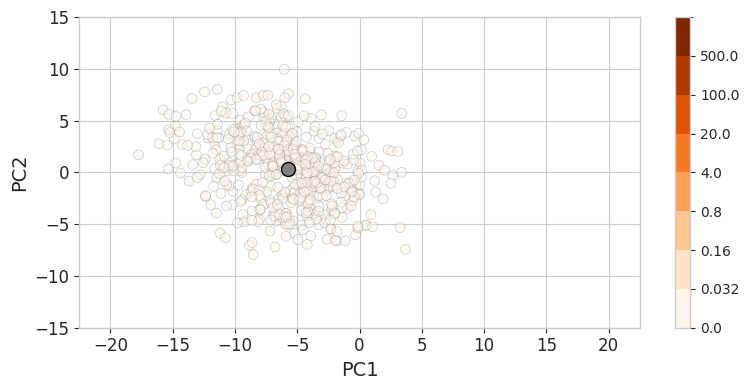

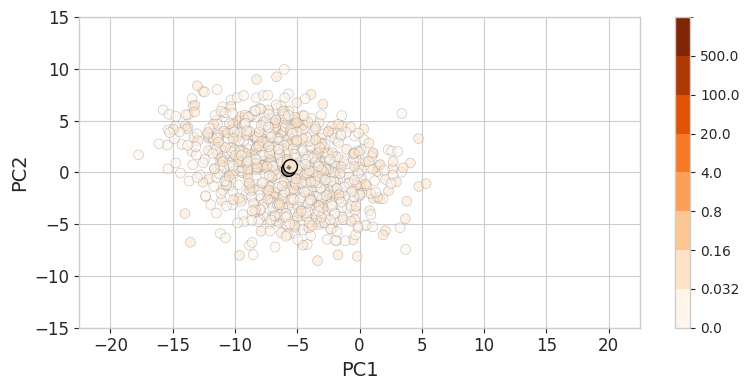

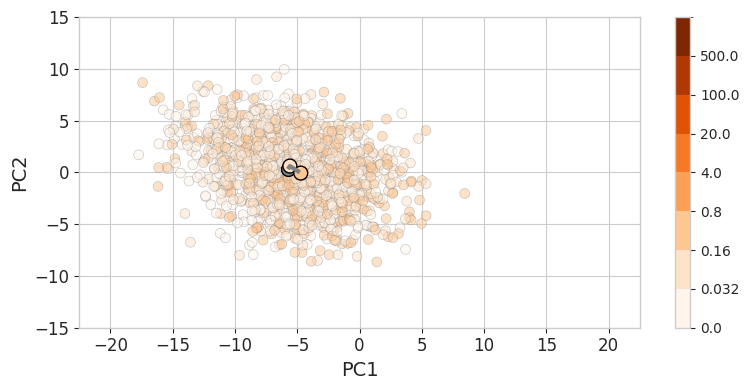

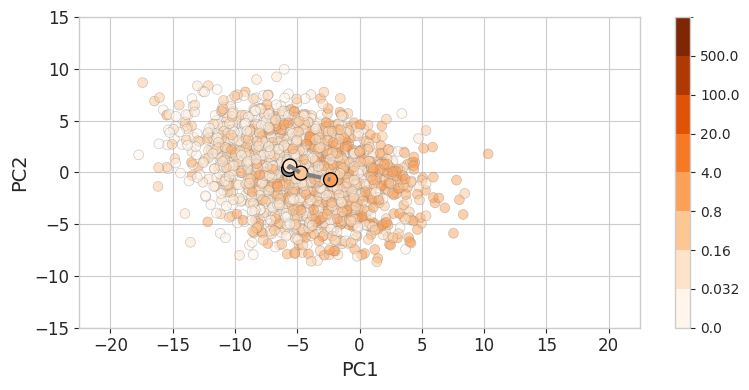

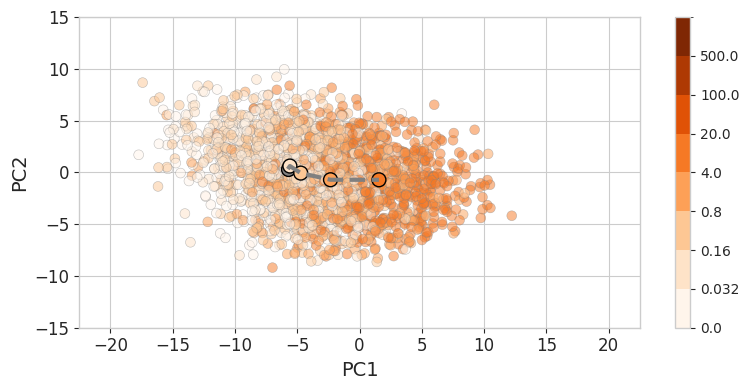

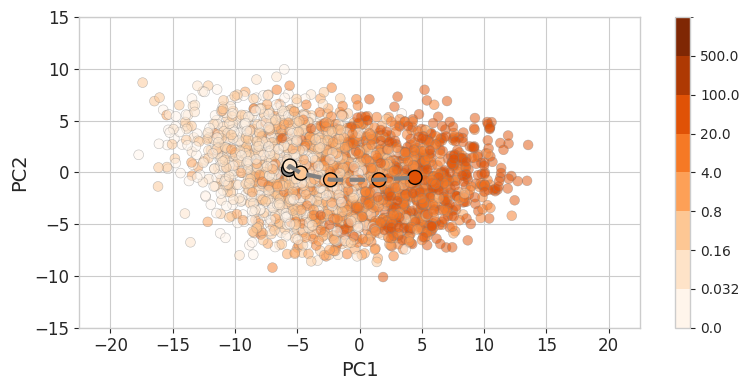

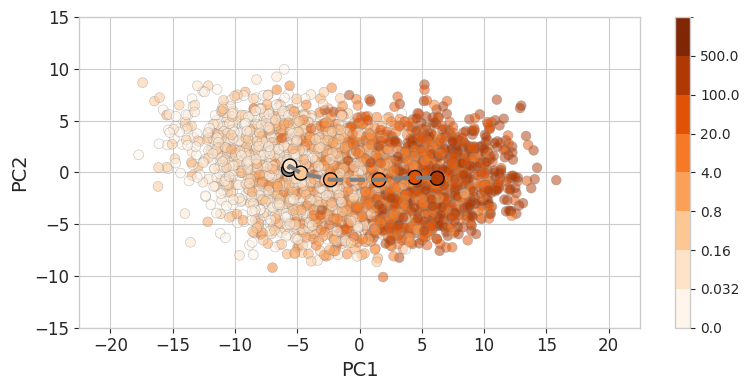

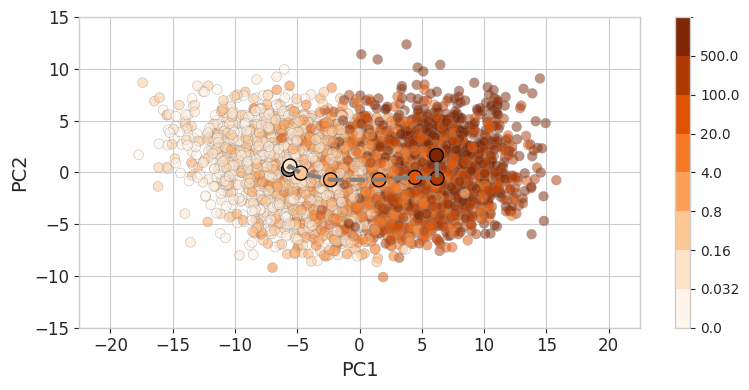

In [21]:
plot_pca_progressive(bmp4_model.pca_sc_fitted_df,
    bmp4_model.pca_mean_fitted_df,
    bmp4_model.exp_var_sc_dict,
    color_column="concentration",
    save=True,
    plot_mean=True
)

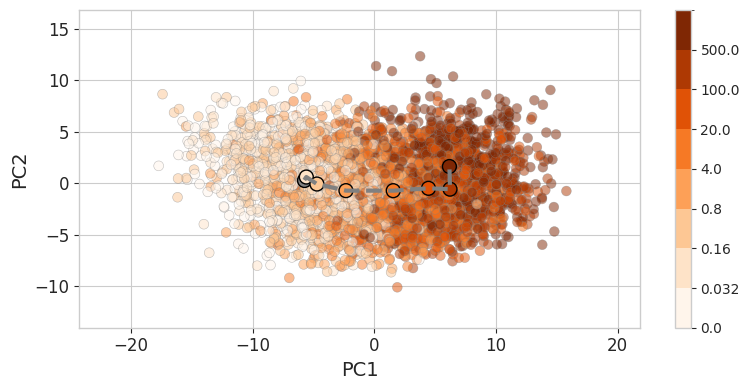

In [19]:
plot_pca_results(
    bmp4_model.pca_sc_fitted_df,
    bmp4_model.pca_mean_fitted_df,
    bmp4_model.exp_var_sc_dict,
    color_column="concentration",
    save=True,
    plot_mean=True,
)

### Supplementary Plot (B): BMP4 PC1 vs H2BCITRINE Correlation Line

In [9]:
pca_df_bmp4 = get_pca_df_with_h2b(bmp4_model, h2b_vec)
corr_dict_df = generate_correlation_dict(pca_df_bmp4)

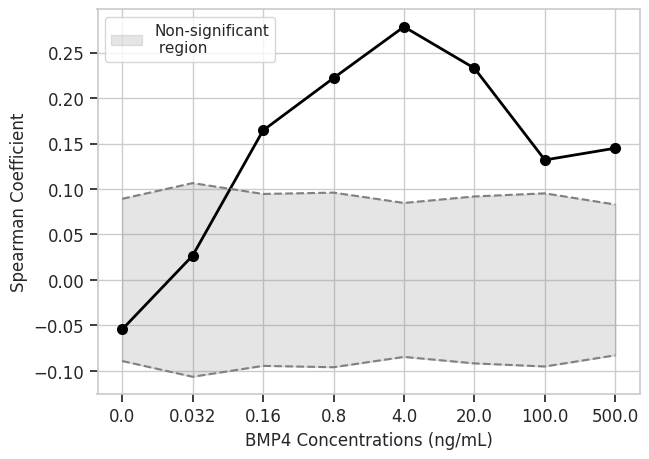

In [18]:
plot_pc1_h2b_corr_line(corr_dict_df, ligand="BMP4", save=True)

### Supplementary plot (C): BMP4 PC1 Weights

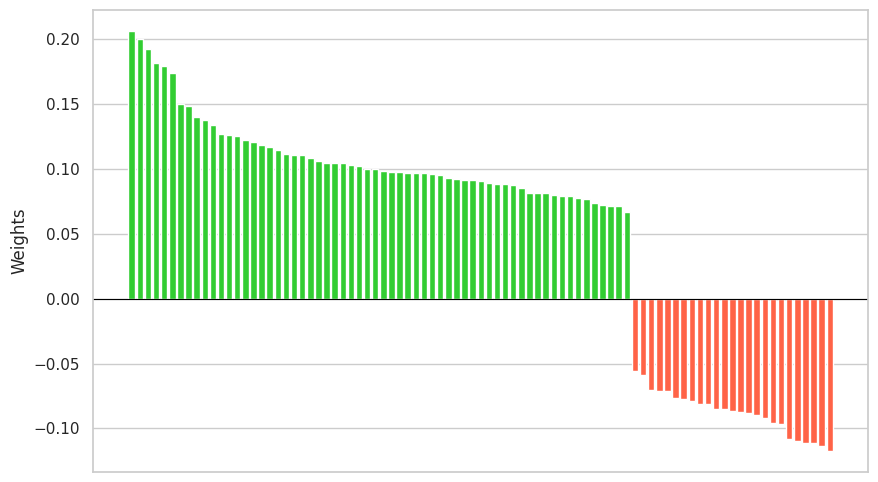

In [ ]:
bmp4_pca_weights_df = extract_pca_weights(bmp4_model)
plot_weights_bar_plot(bmp4_pca_weights_df, save=True)


### Supplementary plot (Removed): BMP4 vs. H2BCITRINE separated by concentrations

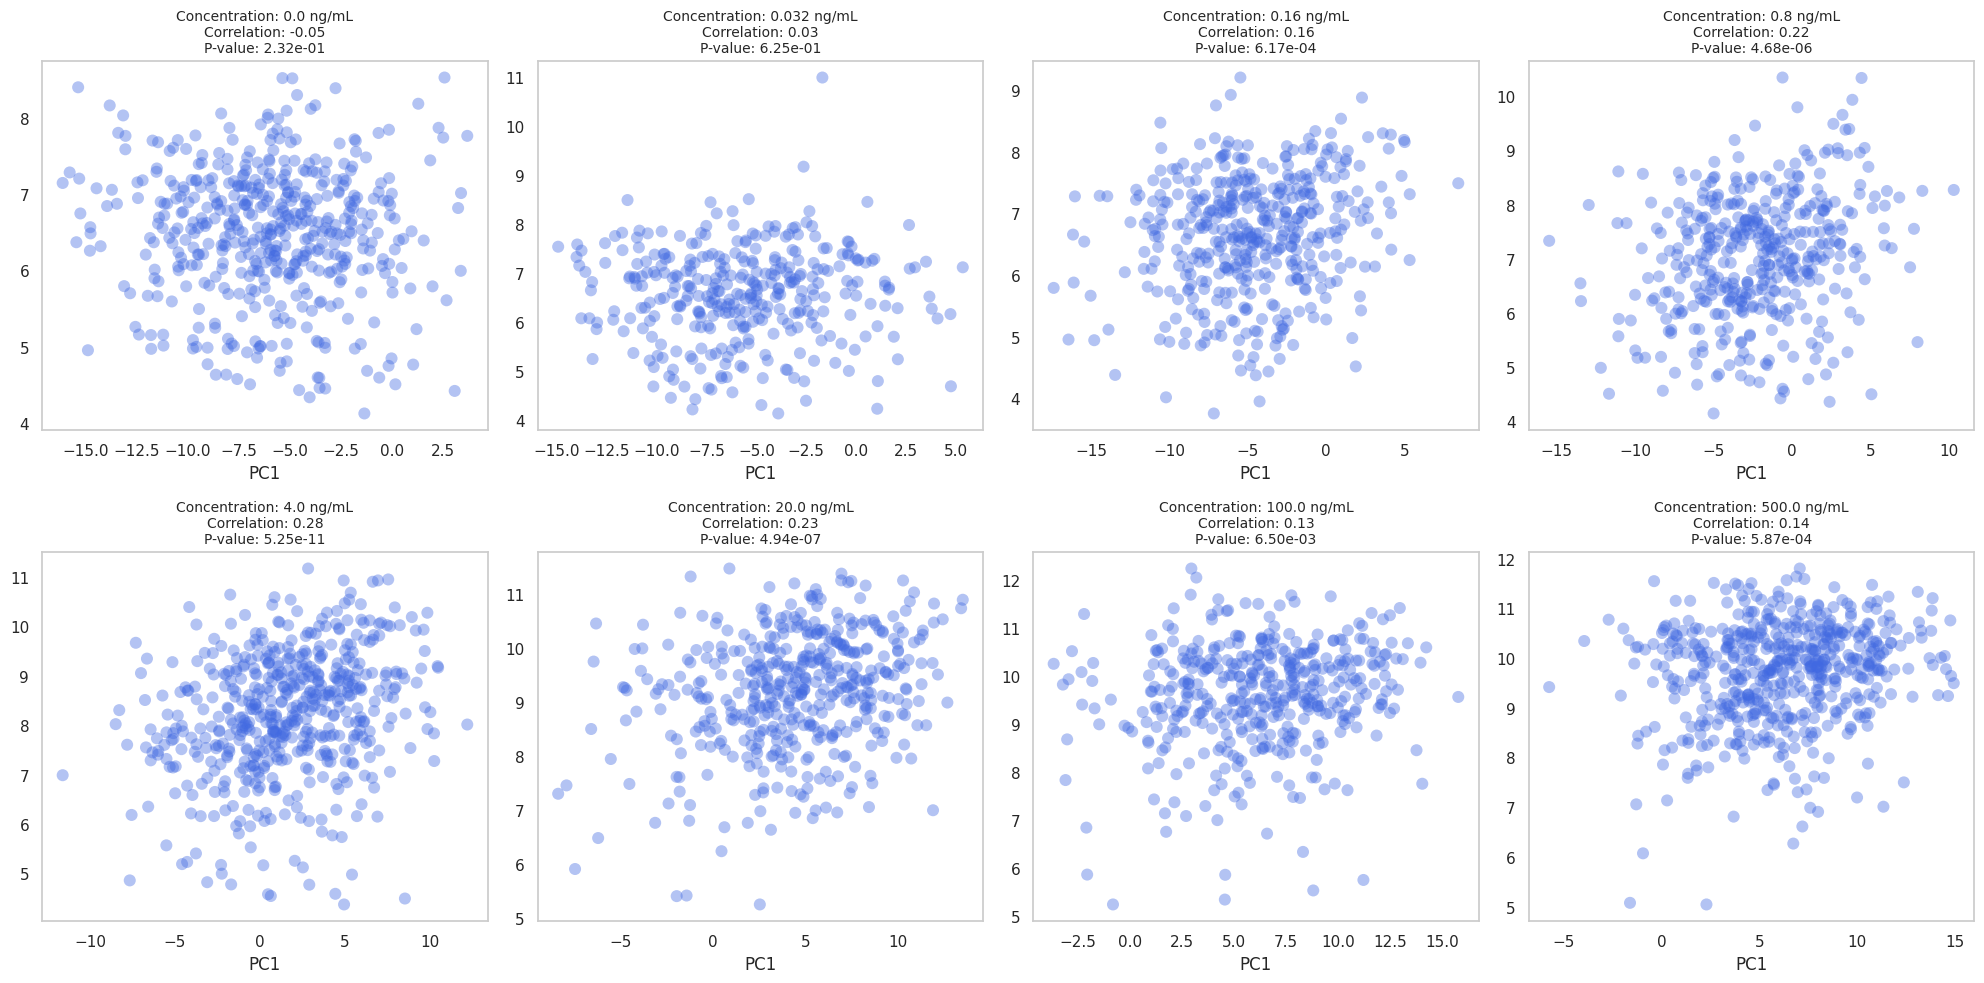

In [ ]:
plot_pca_vs_h2b_across_concentration(pca_df_bmp4, save=True)


### Supplementary Plot D-H: Ligands Single Cell PC1 vs. Concentration Boxplot

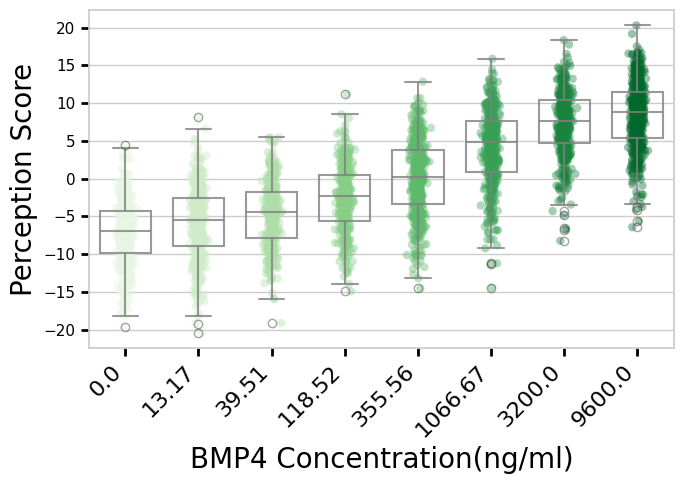

In [19]:
plot_pc1_concentration_boxplot(bmp6_model.pca_sc_fitted_df, save=True)

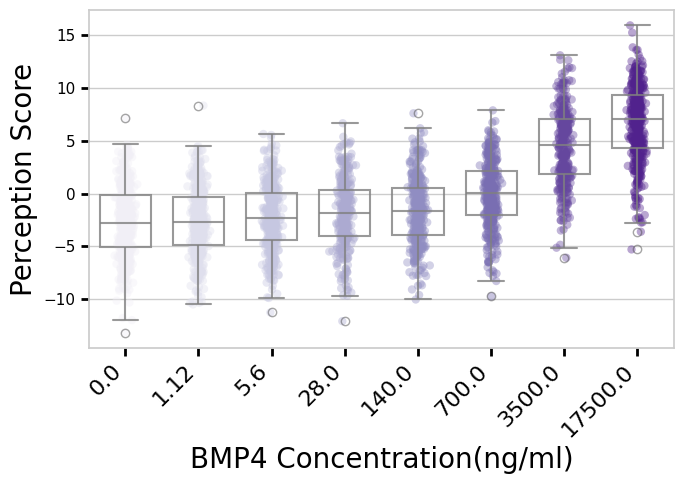

In [20]:
plot_pc1_concentration_boxplot(gdf5_model.pca_sc_fitted_df, save=True)

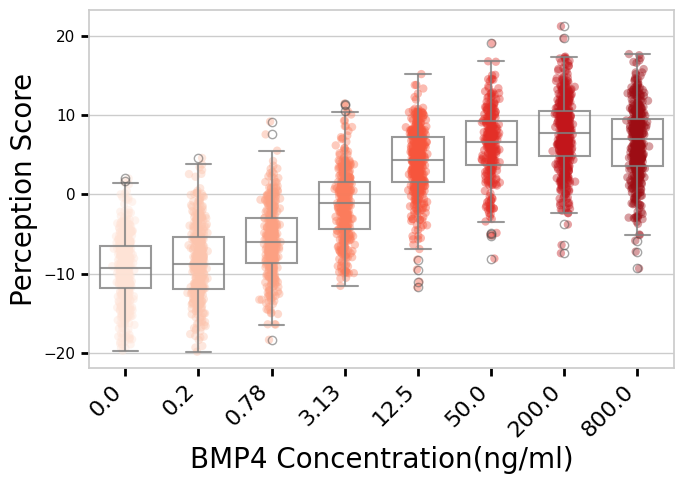

In [21]:
plot_pc1_concentration_boxplot(bmp9_model.pca_sc_fitted_df, reverse=False, save=True)

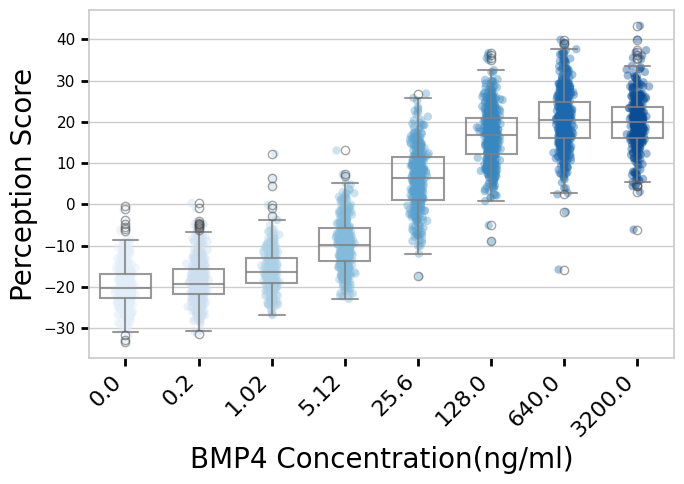

In [22]:
plot_pc1_concentration_boxplot(bmp10_model.pca_sc_fitted_df, reverse=False, save=True)

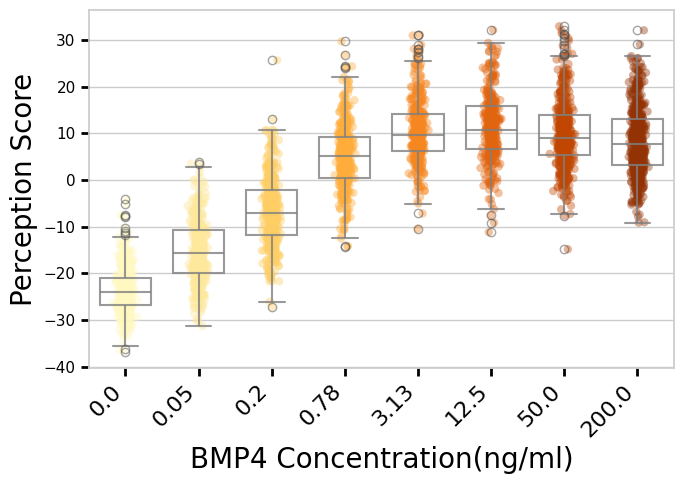

In [24]:
plot_pc1_concentration_boxplot(tgfb1_model.pca_sc_fitted_df, reverse=True, save=True)